[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO/blob/main/Perotti_6_fMRI_ML_v2.ipynb)

In [ ]:
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

# fMRI Machine Learning: From 4D Tensors to Classification

**Goal**: Learn to work with 4D fMRI data and build a machine learning classifier to distinguish between brain activity when viewing faces vs. houses.

**Dataset**: Haxby face/house fMRI dataset
- 216 brain scans (time points)
- 64 × 64 × 40 voxels per scan
- 2 categories: faces and houses
- 12 experimental runs

---

**Key Concepts**:
- Understanding 4D neuroimaging data structure
- Visualizing brain slices in different planes
- Proper train/test splitting for fMRI (by runs, not random!)
- Dimensionality reduction with t-SNE
- Classification and evaluation metrics

## Step 1: Install and Import Libraries

In [1]:
# Install nilearn if needed (uncomment if running in Colab)
#!pip install nilearn

In [2]:
# Basic Python libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Neuroscience libraries
from nilearn.image import index_img
from nilearn import datasets
import nibabel as nib

# Machine learning libraries
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Settings
import warnings
warnings.filterwarnings('ignore')
np.set_printoptions(legacy='1.13')  # Fix numpy printing

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Step 2: Load the Haxby Dataset

The Haxby dataset is a classic fMRI study investigating how the brain processes faces versus objects.

**What we're loading:**
- `func`: Functional MRI data (4D: time × x × y × z)
- `session_target`: Labels for each time point (face, house, etc.)
- `mask`: Brain mask defining which voxels are inside the brain

In [3]:
# Download the Haxby dataset (will cache locally after first download)
haxby_dataset = datasets.fetch_haxby()

print("Dataset files:")
for key in haxby_dataset.keys():
    print(f"  {key}: {type(haxby_dataset[key])}")

[fetch_haxby] Dataset found in /Users/alan/nilearn_data/haxby2001

Dataset files:
  anat: <class 'list'>
  func: <class 'list'>
  session_target: <class 'list'>
  mask_vt: <class 'list'>
  mask_face: <class 'list'>
  mask_house: <class 'list'>
  mask_face_little: <class 'list'>
  mask_house_little: <class 'list'>
  mask: <class 'str'>
  description: <class 'str'>


## Step 3: Explore the Behavioral Data

Before looking at brain images, let's understand the experimental design.

In [4]:
# Load the behavioral data (what stimuli were shown when)
behavioral_data = pd.read_csv(haxby_dataset.session_target[0], sep=" ")

print(f"Behavioral data shape: {behavioral_data.shape}")
print(f"\nColumns: {list(behavioral_data.columns)}")
print(f"\nFirst few rows:")
behavioral_data.head()

Behavioral data shape: (1452, 2)

Columns: ['labels', 'chunks']

First few rows:


,labels,chunks
0,rest,0
1,rest,0
2,rest,0
3,rest,0
4,rest,0


In [5]:
# What categories were shown to the subject?
print("Stimulus categories:")
print(behavioral_data['labels'].unique())

print(f"\nCategory counts:")
print(behavioral_data['labels'].value_counts())

Stimulus categories:
['rest' 'scissors' 'face' 'cat' 'shoe' 'house' 'scrambledpix' 'bottle'
 'chair']

Category counts:
labels
rest            588
scissors        108
face            108
cat             108
shoe            108
house           108
scrambledpix    108
bottle          108
chair           108
Name: count, dtype: int64


In [6]:
# How many experimental runs?
print("Experimental runs (chunks):")
print(behavioral_data['chunks'].unique())

print(f"\nSamples per run:")
print(behavioral_data['chunks'].value_counts().sort_index())

Experimental runs (chunks):
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Samples per run:
chunks
0     121
1     121
2     121
3     121
4     121
5     121
6     121
7     121
8     121
9     121
10    121
11    121
Name: count, dtype: int64


## Step 4: Select Face vs. House Trials

For this analysis, we'll focus on a binary classification: **faces vs. houses**.

This is a simpler problem than multi-class classification and allows us to focus on the methodology.

In [7]:
# Create a binary mask: True for face/house trials, False for others
labels = behavioral_data["labels"]
labels_mask = ((labels == "face") | (labels == "house"))

print("Binary mask statistics:")
unique, counts = np.unique(labels_mask, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  {val}: {count} samples")

print(f"\n→ We'll use {labels_mask.sum()} samples (face or house)")
print(f"→ We'll ignore {(~labels_mask).sum()} samples (other categories)")

Binary mask statistics:
  False: 1236 samples
  True: 216 samples

→ We'll use 216 samples (face or house)
→ We'll ignore 1236 samples (other categories)


In [8]:
# Extract the labels we care about (face or house)
y = labels[labels_mask].to_numpy()

print("Target variable (y) - class distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} samples ({count/len(y)*100:.1f}%)")

print(f"\n✓ Classes are perfectly balanced!")

Target variable (y) - class distribution:
  face: 108 samples (50.0%)
  house: 108 samples (50.0%)

✓ Classes are perfectly balanced!


In [9]:
# Also extract the run information (we'll need this for proper train/test split)
run = behavioral_data["chunks"][labels_mask].to_numpy()

print("Run distribution for face/house trials:")
unique_runs, counts_per_run = np.unique(run, return_counts=True)
for run_num, count in zip(unique_runs, counts_per_run):
    print(f"  Run {run_num}: {count} samples")

print(f"\n→ Each run has exactly {counts_per_run[0]} face/house trials")

Run distribution for face/house trials:
  Run 0: 18 samples
  Run 1: 18 samples
  Run 2: 18 samples
  Run 3: 18 samples
  Run 4: 18 samples
  Run 5: 18 samples
  Run 6: 18 samples
  Run 7: 18 samples
  Run 8: 18 samples
  Run 9: 18 samples
  Run 10: 18 samples
  Run 11: 18 samples

→ Each run has exactly 18 face/house trials


## Step 5: Load the fMRI Data

Now we'll load the actual brain images. This is where things get interesting!

**What we're loading:**
- A 4D tensor with dimensions: **(time, x, y, z)**
- Time: 216 brain scans (one per trial)
- X, Y, Z: 3D spatial coordinates of brain voxels

In [10]:
# Load only the face/house trials using our mask
fmri_img = index_img(haxby_dataset.func[0], labels_mask)

# Convert to numpy array and transpose to (time, x, y, z)
fmri_tensor = fmri_img.get_fdata().T

print(f"fMRI tensor shape: {fmri_tensor.shape}")
print(f"\nDimension breakdown:")
print(f"  Dimension 0 (time):  {fmri_tensor.shape[0]} brain scans")
print(f"  Dimension 1 (X):     {fmri_tensor.shape[1]} voxels (left ↔ right)")
print(f"  Dimension 2 (Y):     {fmri_tensor.shape[2]} voxels (back ↔ front)")
print(f"  Dimension 3 (Z):     {fmri_tensor.shape[3]} voxels (bottom ↔ top)")
print(f"\nTotal voxels per scan: {fmri_tensor.shape[1] * fmri_tensor.shape[2] * fmri_tensor.shape[3]:,}")

fMRI tensor shape: (216, 64, 64, 40)

Dimension breakdown:
  Dimension 0 (time):  216 brain scans
  Dimension 1 (X):     64 voxels (left ↔ right)
  Dimension 2 (Y):     64 voxels (back ↔ front)
  Dimension 3 (Z):     40 voxels (bottom ↔ top)

Total voxels per scan: 163,840


## Step 6: Visualizing Brain Slices

We can visualize the 3D brain by taking 2D "slices" through different planes:

1. **Sagittal** (slice through X): View from the side (left/right)
2. **Coronal** (slice through Y): View from the front/back
3. **Axial** (slice through Z): View from the top/bottom

This is similar to how MRI scans are viewed in medical imaging.

In [11]:
def brain_slice_plotter(datablock, indexes):
    """
    Visualize 3D brain slices from a 4D fMRI tensor.
    
    Parameters
    ----------
    datablock : ndarray, shape (time, x, y, z)
        4D fMRI data tensor
    indexes : list of int
        [time_idx, x_idx, y_idx, z_idx] - indices to slice at
        If empty list, uses random indices
        
    Returns
    -------
    None (displays plots)
    """
    # If no indices provided, use random ones
    if indexes == []:
        indexes = [np.random.randint(datablock.shape[i]) for i in range(4)]
    
    it, ix, iy, iz = indexes
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Sagittal slice (looking from the side)
    im1 = axes[0].imshow(datablock[it, ix, :, :].T, cmap='Blues', origin='lower')
    axes[0].set_title(f'Sagittal Slice (X={ix})\nTime point: {it}', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Y (back → front)', fontsize=10)
    axes[0].set_ylabel('Z (bottom → top)', fontsize=10)
    plt.colorbar(im1, ax=axes[0], label='BOLD signal', fraction=0.046)
    
    # Coronal slice (looking from front/back)
    im2 = axes[1].imshow(datablock[it, :, iy, :].T, cmap='Blues', origin='lower')
    axes[1].set_title(f'Coronal Slice (Y={iy})\nTime point: {it}', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('X (left → right)', fontsize=10)
    axes[1].set_ylabel('Z (bottom → top)', fontsize=10)
    plt.colorbar(im2, ax=axes[1], label='BOLD signal', fraction=0.046)
    
    # Axial slice (looking from top/bottom)
    im3 = axes[2].imshow(datablock[it, :, :, iz].T, cmap='Blues', origin='lower')
    axes[2].set_title(f'Axial Slice (Z={iz})\nTime point: {it}', fontweight='bold', fontsize=12)
    axes[2].set_xlabel('X (left → right)', fontsize=10)
    axes[2].set_ylabel('Y (back → front)', fontsize=10)
    plt.colorbar(im3, ax=axes[2], label='BOLD signal', fraction=0.046)
    
    plt.tight_layout()
    plt.show()

print("✓ Brain slice plotter function defined")

✓ Brain slice plotter function defined


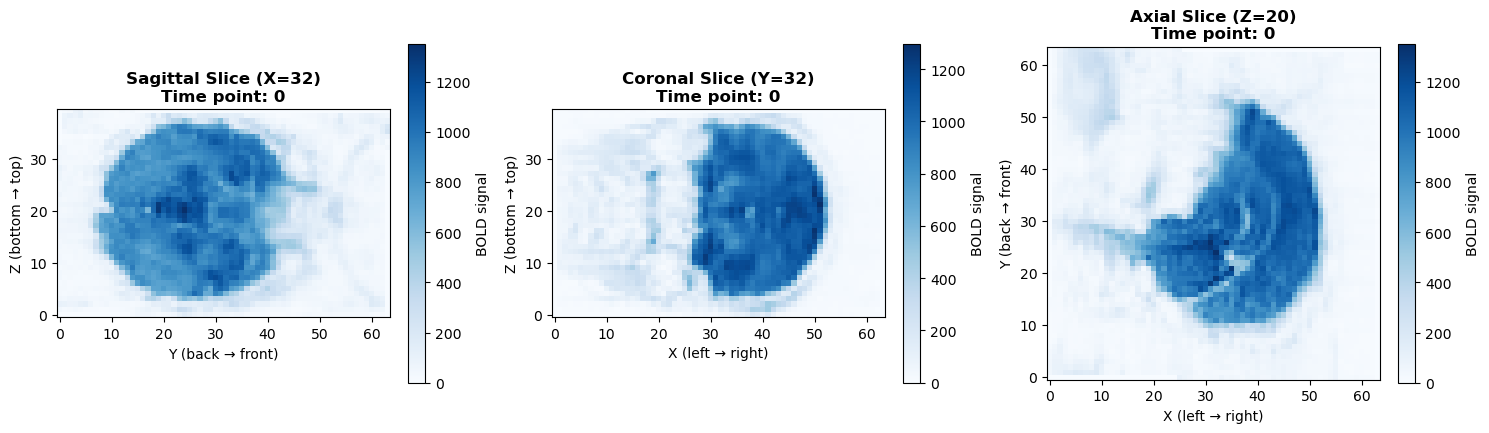

In [12]:
# Visualize the first time point (t=0)
# Using slices near the center of the brain
brain_slice_plotter(fmri_tensor, [0, 32, 32, 20])

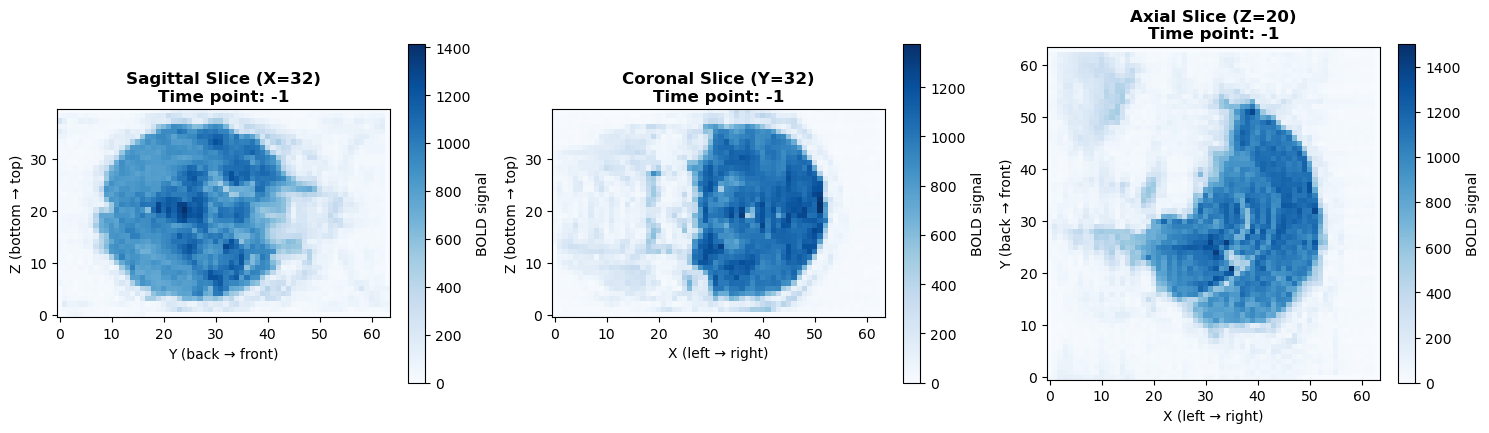

In [13]:
# Visualize the last time point (t=-1)
brain_slice_plotter(fmri_tensor, [-1, 32, 32, 20])

## Step 7: Comparing Face vs. House Activation

Now let's compare brain activity when viewing faces vs. houses.

**Key question**: Are there visible differences in activation patterns?

In [14]:
# Find indices for face and house trials
face_indices = np.where(y == 'face')[0]
house_indices = np.where(y == 'house')[0]

print(f"Number of face trials: {len(face_indices)}")
print(f"Number of house trials: {len(house_indices)}")
print(f"\nFirst few face trial indices: {face_indices[:5]}")
print(f"First few house trial indices: {house_indices[:5]}")

Number of face trials: 108
Number of house trials: 108

First few face trial indices: [0 1 2 3 4]
First few house trial indices: [ 9 10 11 12 13]


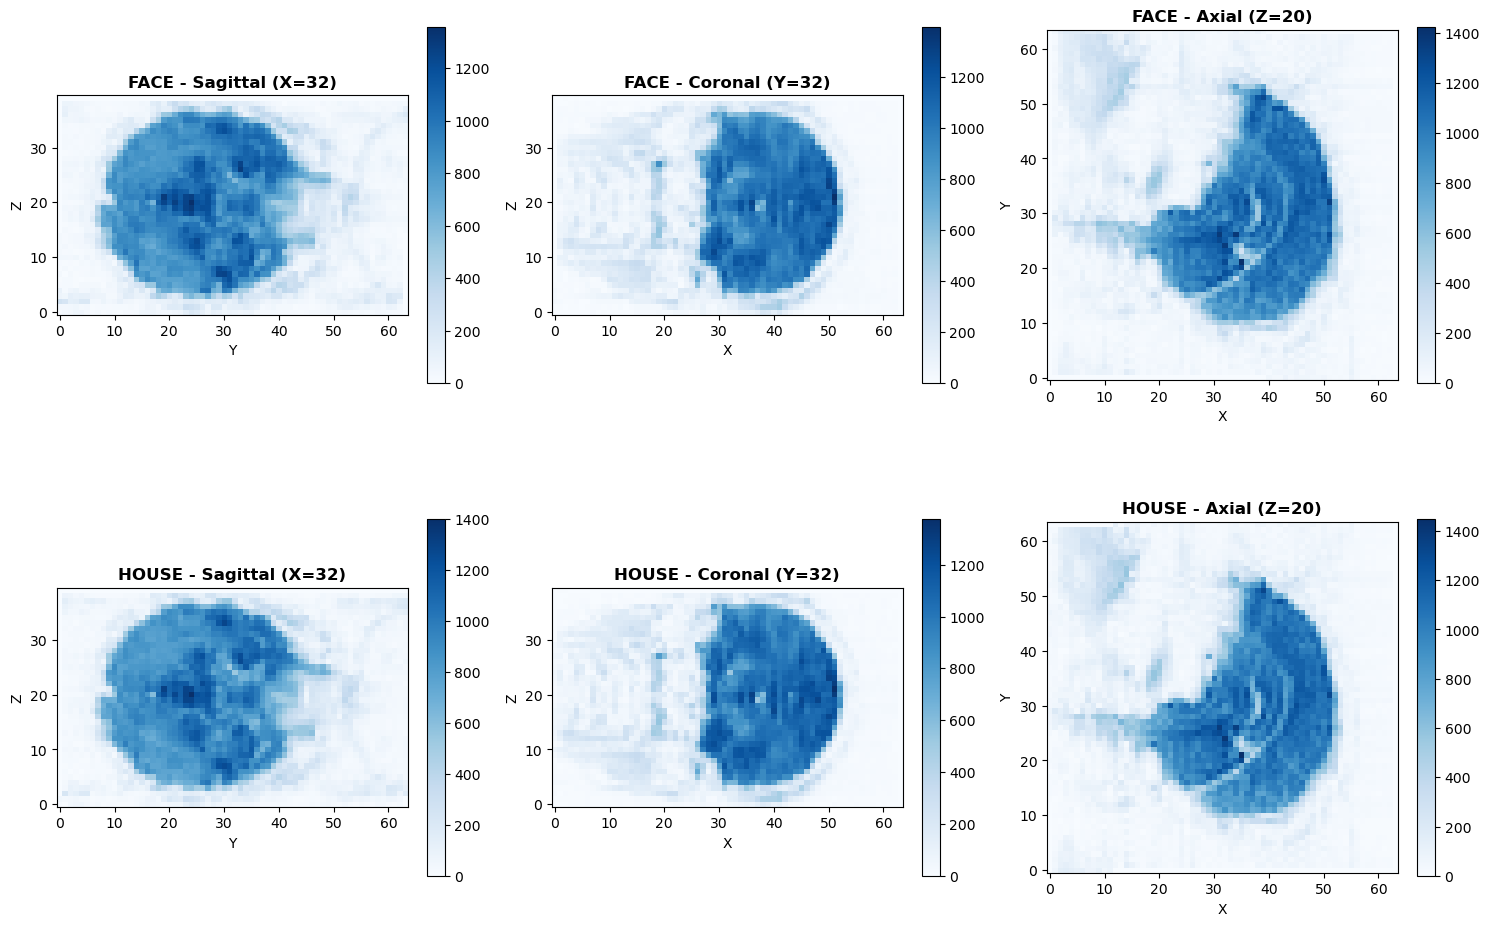

💡 Observations:
   The differences are subtle in individual trials.
   Let's compute averages across ALL trials to see clearer patterns.


In [15]:
# Compare a single face trial vs. a single house trial
face_t = face_indices[10]   # Pick the 10th face trial
house_t = house_indices[10]  # Pick the 10th house trial
slice_x, slice_y, slice_z = 32, 32, 20  # Slices near the center

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Face trial - three views
im1 = axes[0, 0].imshow(fmri_tensor[face_t, slice_x, :, :].T, cmap='Blues', origin='lower')
axes[0, 0].set_title(f'FACE - Sagittal (X={slice_x})', fontweight='bold')
axes[0, 0].set_xlabel('Y')
axes[0, 0].set_ylabel('Z')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

im2 = axes[0, 1].imshow(fmri_tensor[face_t, :, slice_y, :].T, cmap='Blues', origin='lower')
axes[0, 1].set_title(f'FACE - Coronal (Y={slice_y})', fontweight='bold')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Z')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

im3 = axes[0, 2].imshow(fmri_tensor[face_t, :, :, slice_z].T, cmap='Blues', origin='lower')
axes[0, 2].set_title(f'FACE - Axial (Z={slice_z})', fontweight='bold')
axes[0, 2].set_xlabel('X')
axes[0, 2].set_ylabel('Y')
plt.colorbar(im3, ax=axes[0, 2], fraction=0.046)

# House trial - three views
im4 = axes[1, 0].imshow(fmri_tensor[house_t, slice_x, :, :].T, cmap='Blues', origin='lower')
axes[1, 0].set_title(f'HOUSE - Sagittal (X={slice_x})', fontweight='bold')
axes[1, 0].set_xlabel('Y')
axes[1, 0].set_ylabel('Z')
plt.colorbar(im4, ax=axes[1, 0], fraction=0.046)

im5 = axes[1, 1].imshow(fmri_tensor[house_t, :, slice_y, :].T, cmap='Blues', origin='lower')
axes[1, 1].set_title(f'HOUSE - Coronal (Y={slice_y})', fontweight='bold')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Z')
plt.colorbar(im5, ax=axes[1, 1], fraction=0.046)

im6 = axes[1, 2].imshow(fmri_tensor[house_t, :, :, slice_z].T, cmap='Blues', origin='lower')
axes[1, 2].set_title(f'HOUSE - Axial (Z={slice_z})', fontweight='bold')
axes[1, 2].set_xlabel('X')
axes[1, 2].set_ylabel('Y')
plt.colorbar(im6, ax=axes[1, 2], fraction=0.046)

plt.tight_layout()
plt.show()

print("💡 Observations:")
print("   The differences are subtle in individual trials.")
print("   Let's compute averages across ALL trials to see clearer patterns.")

## Step 8: Average Activation Maps

To reduce noise and see clearer patterns, we'll compute the **average brain activation** across all face trials and all house trials.

In [16]:
# Compute mean activation for each category
mean_face = np.mean(fmri_tensor[face_indices], axis=0)
mean_house = np.mean(fmri_tensor[house_indices], axis=0)

# Compute the difference (face - house)
difference = mean_face - mean_house

print(f"Mean face activation shape: {mean_face.shape}")
print(f"Mean house activation shape: {mean_house.shape}")
print(f"Difference map shape: {difference.shape}")
print(f"\nDifference statistics:")
print(f"  Min: {difference.min():.3f}")
print(f"  Max: {difference.max():.3f}")
print(f"  Mean: {difference.mean():.3f}")
print(f"  Std: {difference.std():.3f}")

Mean face activation shape: (64, 64, 40)
Mean house activation shape: (64, 64, 40)
Difference map shape: (64, 64, 40)

Difference statistics:
  Min: -69.731
  Max: 82.259
  Mean: -0.051
  Std: 4.022


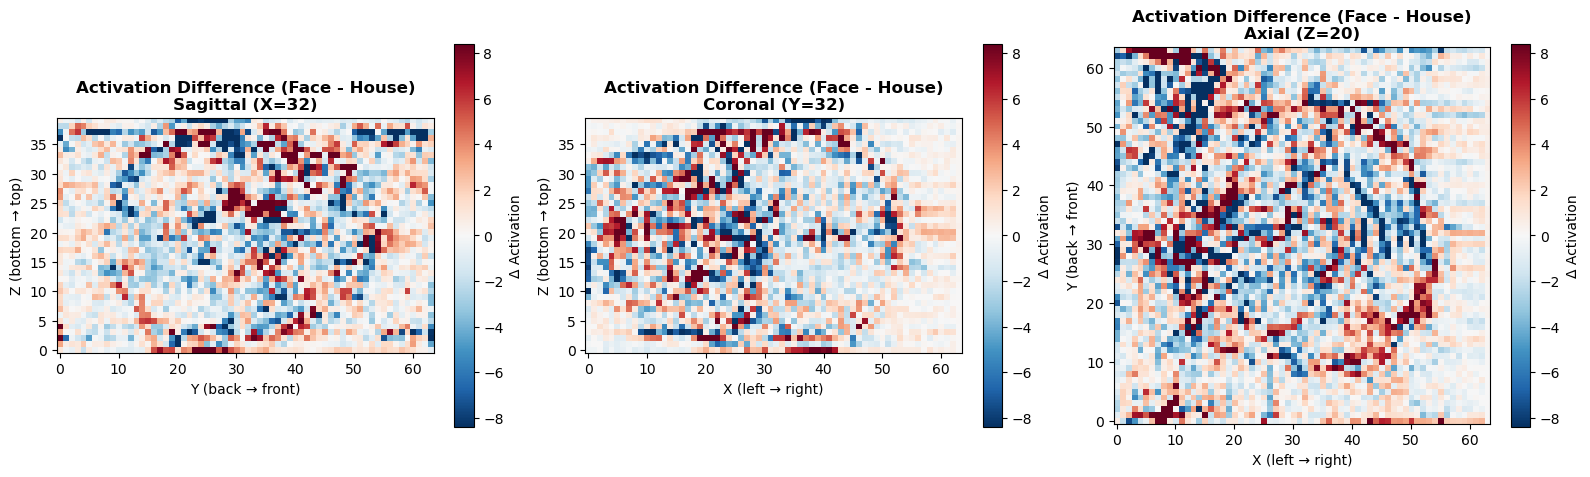


📊 Interpretation:
   🔴 Red regions: More active when viewing FACES
   🔵 Blue regions: More active when viewing HOUSES
   ⚪ White regions: Similar activation for both

💡 Note: Colors scaled to 95th percentile for better visibility
   This shows the brain has specialized regions for different visual categories!


In [17]:
# Visualize the DIFFERENCE between face and house activation
# This shows which regions are MORE active for faces vs. houses
slice_x, slice_y, slice_z = 32, 32, 20

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Use percentile-based scaling for better contrast
# This makes the colors more saturated and differences more visible
vmax = np.percentile(np.abs(difference), 95)  # Use 95th percentile instead of max
vmin = -vmax

im1 = axes[0].imshow(difference[slice_x, :, :].T, cmap='RdBu_r',
                     origin='lower', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Activation Difference (Face - House)\nSagittal (X={slice_x})',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Y (back → front)', fontsize=10)
axes[0].set_ylabel('Z (bottom → top)', fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Δ Activation', fraction=0.046)

im2 = axes[1].imshow(difference[:, slice_y, :].T, cmap='RdBu_r',
                     origin='lower', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Activation Difference (Face - House)\nCoronal (Y={slice_y})',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('X (left → right)', fontsize=10)
axes[1].set_ylabel('Z (bottom → top)', fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Δ Activation', fraction=0.046)

im3 = axes[2].imshow(difference[:, :, slice_z].T, cmap='RdBu_r',
                     origin='lower', vmin=vmin, vmax=vmax)
axes[2].set_title(f'Activation Difference (Face - House)\nAxial (Z={slice_z})',
                  fontweight='bold', fontsize=12)
axes[2].set_xlabel('X (left → right)', fontsize=10)
axes[2].set_ylabel('Y (back → front)', fontsize=10)
plt.colorbar(im3, ax=axes[2], label='Δ Activation', fraction=0.046)

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   🔴 Red regions: More active when viewing FACES")
print("   🔵 Blue regions: More active when viewing HOUSES")
print("   ⚪ White regions: Similar activation for both")
print("\n💡 Note: Colors scaled to 95th percentile for better visibility")
print("   This shows the brain has specialized regions for different visual categories!")

## Step 9: Flatten the Data for Machine Learning

Most ML algorithms expect 2D input: (samples, features)

We need to convert:
- From: **(216, 64, 64, 40)** → 216 samples with 3D structure
- To: **(216, 163840)** → 216 samples with flat features

In [18]:
# Flatten the 4D tensor to 2D
# -1 means "compute this dimension automatically"
flat_fmri = fmri_tensor.reshape((216, -1))

print(f"Original shape: {fmri_tensor.shape}")
print(f"Flattened shape: {flat_fmri.shape}")
print(f"\nInterpretation:")
print(f"  {flat_fmri.shape[0]} samples (brain scans)")
print(f"  {flat_fmri.shape[1]:,} features (voxels)")
print(f"\n✓ Ready for machine learning!")

Original shape: (216, 64, 64, 40)
Flattened shape: (216, 163840)

Interpretation:
  216 samples (brain scans)
  163,840 features (voxels)

✓ Ready for machine learning!


## Step 10: Dimensionality Reduction with t-SNE

Before training, let's visualize the data in 2D using t-SNE.

**t-SNE** (t-Distributed Stochastic Neighbor Embedding):
- Reduces high-dimensional data to 2D/3D for visualization
- Preserves local structure (similar samples stay close together)
- Helps us understand if the data is separable

In [19]:
# Run t-SNE: 163,840 features → 2 features
print("Running t-SNE... (this may take a minute)")
tsne = TSNE(n_components=2, verbose=0, perplexity=10, max_iter=300, random_state=42)
tsned = tsne.fit_transform(np.nan_to_num(flat_fmri, nan=0))

print(f"\nt-SNE output shape: {tsned.shape}")
print(f"  {tsned.shape[0]} samples")
print(f"  {tsned.shape[1]} t-SNE components")
print("\n✓ t-SNE completed!")

Running t-SNE... (this may take a minute)

t-SNE output shape: (216, 2)
  216 samples
  2 t-SNE components

✓ t-SNE completed!


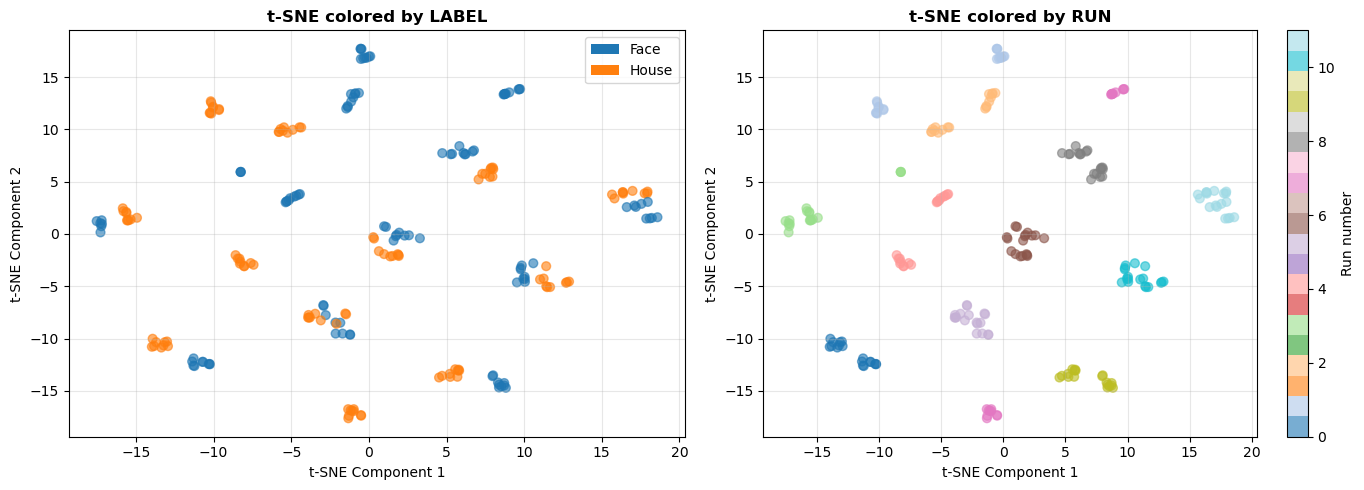


💡 Key Observations:
   LEFT: Face and house trials show some separation (good for classification!)
   RIGHT: Different runs cluster together (temporal structure!)

⚠️  CRITICAL: We must split by RUNS, not randomly!
   Random splitting would leak information between train/test.


In [20]:
# Visualize t-SNE results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Colored by label (face vs house)
colors_label = ['#1f77b4' if label == 'face' else '#ff7f0e' for label in y]
axes[0].scatter(tsned[:, 0], tsned[:, 1], c=colors_label, alpha=0.6, s=40)
axes[0].set_title('t-SNE colored by LABEL', fontweight='bold', fontsize=12)
axes[0].set_xlabel('t-SNE Component 1', fontsize=10)
axes[0].set_ylabel('t-SNE Component 2', fontsize=10)
axes[0].grid(alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Face'),
                  Patch(facecolor='#ff7f0e', label='House')]
axes[0].legend(handles=legend_elements, loc='best')

# Plot 2: Colored by run
scatter = axes[1].scatter(tsned[:, 0], tsned[:, 1], c=run, cmap='tab20', alpha=0.6, s=40)
axes[1].set_title('t-SNE colored by RUN', fontweight='bold', fontsize=12)
axes[1].set_xlabel('t-SNE Component 1', fontsize=10)
axes[1].set_ylabel('t-SNE Component 2', fontsize=10)
axes[1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Run number')

plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("   LEFT: Face and house trials show some separation (good for classification!)")
print("   RIGHT: Different runs cluster together (temporal structure!)")
print("\n⚠️  CRITICAL: We must split by RUNS, not randomly!")
print("   Random splitting would leak information between train/test.")

## Step 11: Train/Test Split by Runs

**Why split by runs?**
- fMRI data has temporal dependencies within runs
- Random splitting would leak information (data from same run in both train/test)
- We want to test on completely independent data

**Strategy**: Hold out 3 runs (25%) for testing

In [21]:
# Arbitrary decision: runs 3, 5, 7 go to test set
# (Spread across early, middle, late in the experiment)
test_runs = [3, 5, 7]

# Create train/test indices based on runs
train_index = np.where(~np.isin(run, test_runs))[0]
test_index = np.where(np.isin(run, test_runs))[0]

# Split the data
xtrn, xtst = flat_fmri[train_index], flat_fmri[test_index]
ytrn, ytst = y[train_index], y[test_index]

print(f"Train set: {xtrn.shape[0]} samples ({xtrn.shape[0]/len(flat_fmri)*100:.1f}%)")
print(f"Test set:  {xtst.shape[0]} samples ({xtst.shape[0]/len(flat_fmri)*100:.1f}%)")
print(f"\nFeatures: {xtrn.shape[1]:,} voxels")

# Check class distribution
print(f"\nTrain class distribution:")
unique_train, counts_train = np.unique(ytrn, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"  {label}: {count} ({count/len(ytrn)*100:.1f}%)")

print(f"\nTest class distribution:")
unique_test, counts_test = np.unique(ytst, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"  {label}: {count} ({count/len(ytst)*100:.1f}%)")

Train set: 162 samples (75.0%)
Test set:  54 samples (25.0%)

Features: 163,840 voxels

Train class distribution:
  face: 81 (50.0%)
  house: 81 (50.0%)

Test class distribution:
  face: 27 (50.0%)
  house: 27 (50.0%)
